In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install librosa matplotlib numpy # librosa only for Audio loading

In [ ]:
import numpy as np
import librosa
from scipy.fftpack import dct

#  1. Pre-emphasis
def pre_emphasis(signal, alpha=0.97):
    return np.append(signal[0], signal[1:] - alpha * signal[:-1])


#  2. Framing
def framing(signal, sr, frame_size=0.025, frame_stride=0.01):
    frame_len = int(frame_size * sr)        # samples per frame
    frame_step = int(frame_stride * sr)     # step size

    signal_length = len(signal)
    num_frames = int(np.ceil((signal_length - frame_len) / frame_step)) + 1

    pad_len = num_frames * frame_step + frame_len
    pad_signal = np.append(signal, np.zeros(pad_len - signal_length))

    indices = np.tile(np.arange(0, frame_len), (num_frames, 1)) + \
              np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_len, 1)).T

    frames = pad_signal[indices.astype(np.int32)]
    return frames


#  3. Windowing (Hamming applied later directly)


#  4. FFT + Power Spectrum
def power_spectrum(frames, NFFT=512):
    fft = np.fft.rfft(frames, NFFT)
    power = (1.0 / NFFT) * (np.abs(fft) ** 2)
    return power


#  5. Mel Filterbank
def mel_filterbank(pow_frames, sr, nfilt=26, NFFT=512):

    # Convert Hz → Mel
    def hz_to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    # Convert Mel → Hz
    def mel_to_hz(mel):
        return 700 * (10**(mel / 2595) - 1)

    low_mel = hz_to_mel(0)
    high_mel = hz_to_mel(sr / 2)

    mel_points = np.linspace(low_mel, high_mel, nfilt + 2)
    hz_points = mel_to_hz(mel_points)

    bins = np.floor((NFFT + 1) * hz_points / sr).astype(int)

    fbank = np.zeros((nfilt, int(NFFT / 2 + 1)))

    for m in range(1, nfilt + 1):
        f_m_minus = bins[m - 1]
        f_m = bins[m]
        f_m_plus = bins[m + 1]

        for k in range(f_m_minus, f_m):
            fbank[m - 1, k] = (k - f_m_minus) / (f_m - f_m_minus + 1e-8)

        for k in range(f_m, f_m_plus):
            fbank[m - 1, k] = (f_m_plus - k) / (f_m_plus - f_m + 1e-8)

    filter_banks = np.dot(pow_frames, fbank.T)

    # Avoid log(0)
    filter_banks = np.where(filter_banks == 0, 1e-10, filter_banks)

    return filter_banks


#  6. Full Pipeline Function
def process_audio(file_path):
    signal, sr = librosa.load(file_path, sr=16000)

    # Step 1: Pre-emphasis
    emphasized = pre_emphasis(signal)

    # Step 2: Framing
    frames = framing(emphasized, sr)

    # Step 3: Windowing
    windowed = frames * np.hamming(frames.shape[1])

    # Step 4: FFT + Power Spectrum
    power_spec = power_spectrum(windowed)

    # Step 5: Mel Filterbank
    mel_energy = mel_filterbank(power_spec, sr)

    # Step 6: Log + DCT → MFCC
    log_energy = np.log(mel_energy)
    mfccs = dct(log_energy, type=2, axis=1, norm='ortho')[:, :13]

    return signal, mfccs, frames

Processed: Audio3.wav
Audio3.wav → MFCC shape: (879, 13)


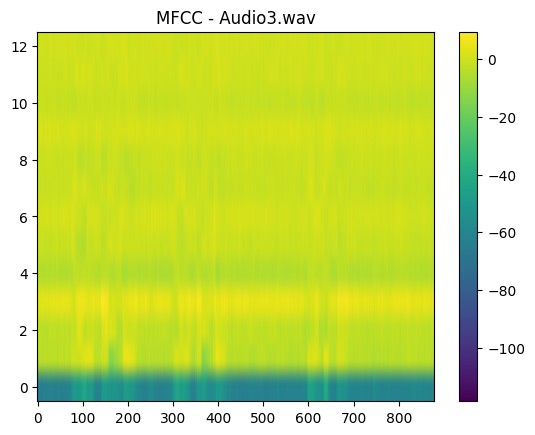

Processed: Audio2.wav
Audio2.wav → MFCC shape: (816, 13)


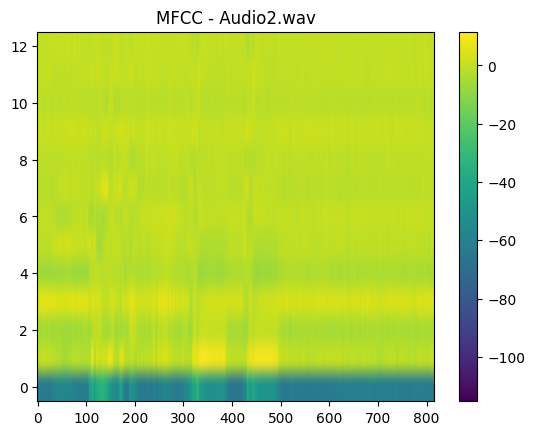

Processed: Audio1.wav
Audio1.wav → MFCC shape: (670, 13)


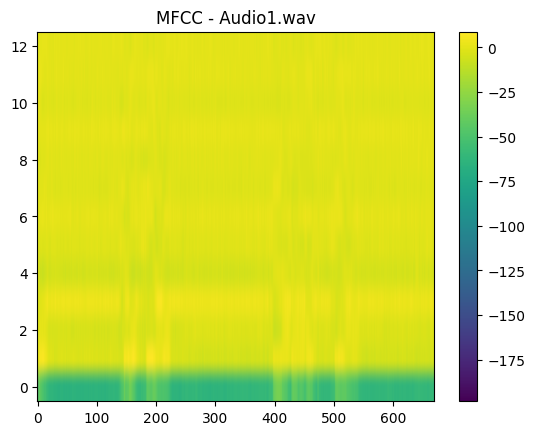

In [ ]:
import os

folder = "/content/drive/MyDrive/audio/"

results = {}


for file in os.listdir(folder):
    if file.endswith(".wav"):
        path = os.path.join(folder, file)

        signal, mfccs, frames = process_audio(path)

        results[file] = {
            "mfcc": mfccs,
            "frames": frames
        }

        print(f"Processed: {file}")
        print(f"{file} → MFCC shape: {mfccs.shape}")


        plt.imshow(mfccs.T, aspect='auto', origin='lower')
        plt.title(f"MFCC - {file}")
        plt.colorbar()
        plt.show()

In [ ]:
#  SNR function
def compute_snr(signal, noisy_signal):
    noise = noisy_signal - signal
    return 10 * np.log10(np.sum(signal ** 2) / (np.sum(noise ** 2) + 1e-10))


#  Window function
def apply_window(signal, type="hamming"):
    if type == "hamming":
        return signal * np.hamming(len(signal))
    elif type == "hanning":
        return signal * np.hanning(len(signal))
    else:
        return signal  # rectangular

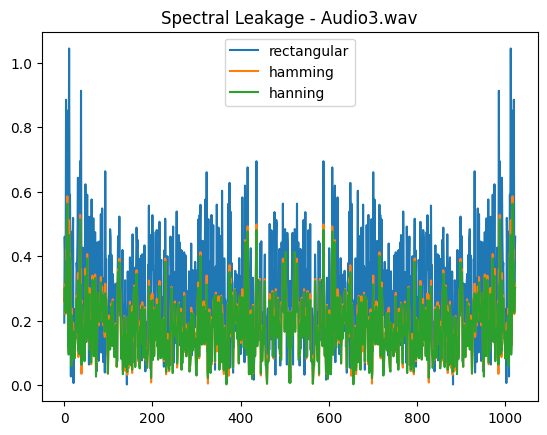

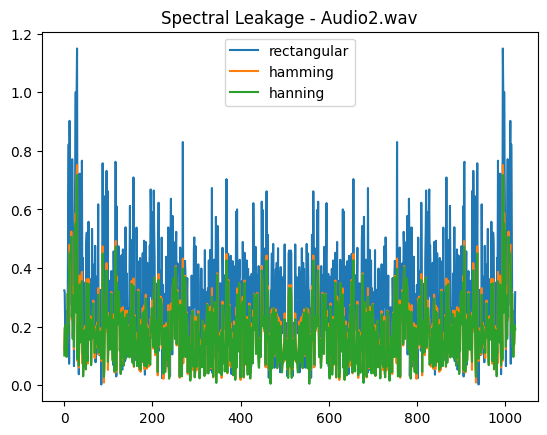

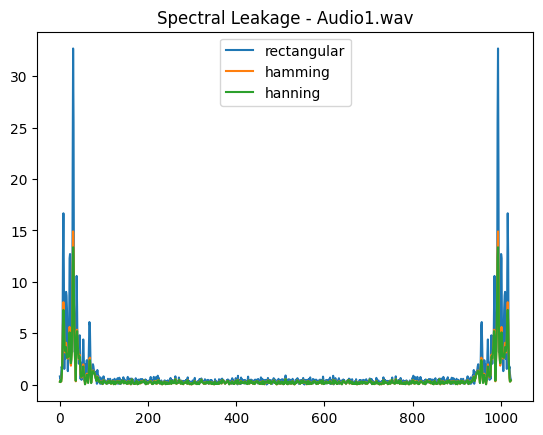


SNR Comparison Table:

window        hamming    hanning  rectangular
file                                         
Audio1.wav  17.635947  17.486150    18.904735
Audio2.wav  -7.674660  -7.744347    -7.031060
Audio3.wav -10.540605 -10.712435    -9.172854


In [ ]:

    folder = "/content/drive/MyDrive/audio"
    files = [f for f in os.listdir(folder) if f.endswith(".wav")]

    snr_results = []

    for file in files:
        path = os.path.join(folder, file)
        signal, _ = librosa.load(path, sr=16000)

        clean = signal[:1024]

        # Add noise
        noise = np.random.normal(0, 0.01, len(clean))
        noisy = clean + noise

        plt.figure()

        for w in ["rectangular", "hamming", "hanning"]:
            # Apply window
            clean_win = apply_window(clean, w)
            noisy_win = apply_window(noisy, w)

            # SNR
            snr = compute_snr(clean_win, noisy_win)

            snr_results.append({
                "file": file,
                "window": w,
                "snr": snr
            })

            # Spectral plot
            spectrum = np.abs(np.fft.fft(noisy_win))
            plt.plot(spectrum, label=w)

        plt.title(f"Spectral Leakage - {file}")
        plt.legend()
        plt.show()

    # Create table
    df = pd.DataFrame(snr_results)
    pivot_table = df.pivot(index="file", columns="window", values="snr")

    print("\nSNR Comparison Table:\n")
    print(pivot_table)

In [ ]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import os

# 🔹 Cepstrum
def cepstrum(signal):
    spectrum = np.fft.fft(signal)
    log_spec = np.log(np.abs(spectrum) + 1e-10)
    return np.fft.ifft(log_spec).real

#  Voiced / Unvoiced Detection
def detect_voiced(frame, threshold=0.1):
    cep = cepstrum(frame)

    high_q = cep[20:100]

    if np.max(high_q) > threshold:
        return 1
    else:
        return 0

#  Framing (reuse logic)
def framing(signal, sr, frame_size=0.025, frame_stride=0.01):
    frame_len = int(frame_size * sr)
    frame_step = int(frame_stride * sr)

    frames = []
    for i in range(0, len(signal) - frame_len, frame_step):
        frames.append(signal[i:i+frame_len])

    return np.array(frames)



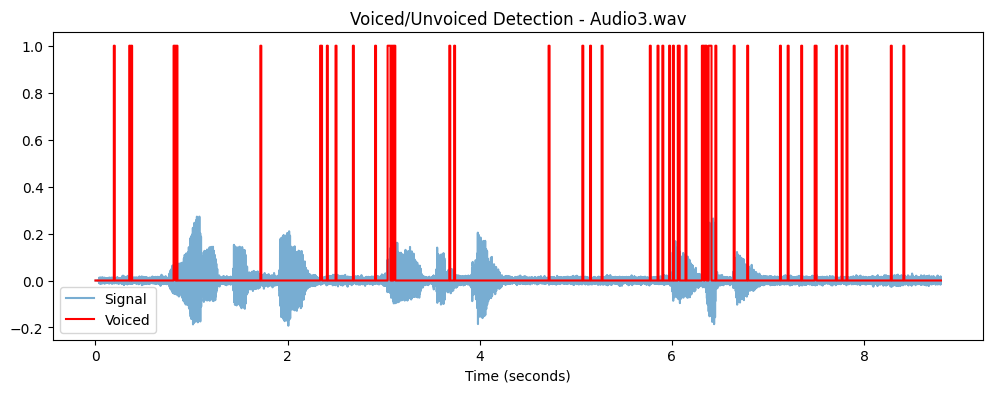

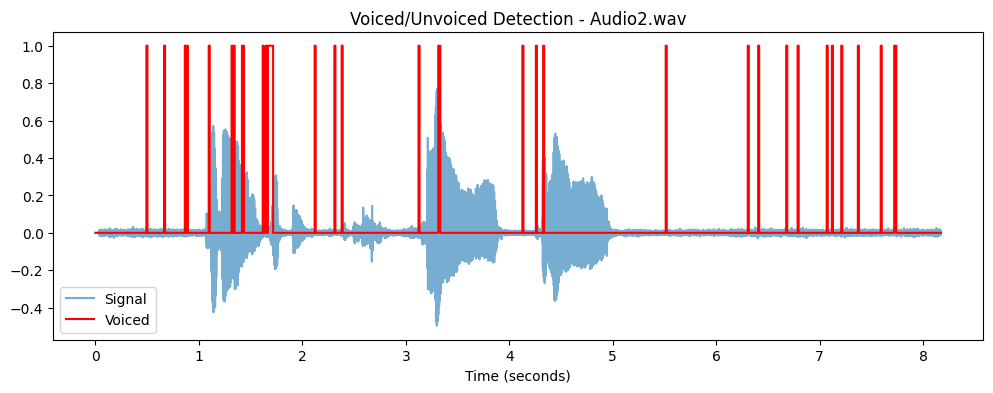

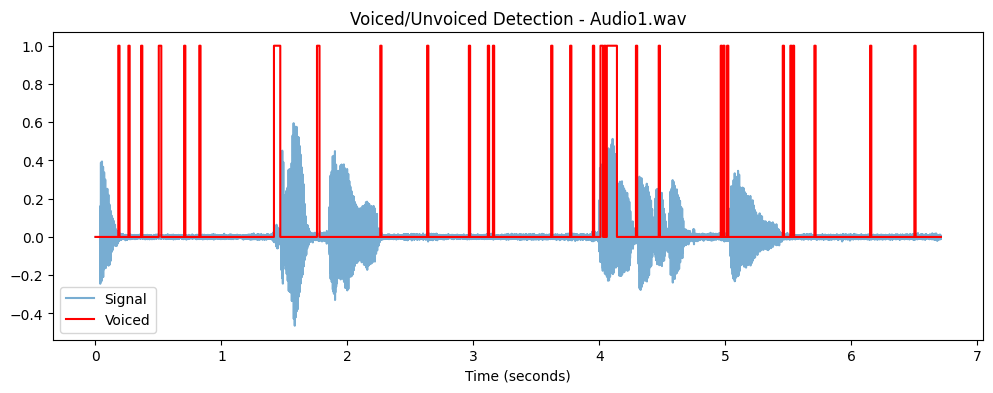

In [ ]:


    folder = "/content/drive/MyDrive/audio/"
    files = [f for f in os.listdir(folder) if f.endswith(".wav")]

    for file in files:
        path = os.path.join(folder, file)

        signal, sr = librosa.load(path, sr=16000)

        # Create frames
        frames = framing(signal, sr)

        # Detect voiced/unvoiced
        voiced_flags = [detect_voiced(f) for f in frames]

        # Time axis
        time_signal = np.linspace(0, len(signal)/sr, len(signal))
        frame_time = np.linspace(0, len(signal)/sr, len(voiced_flags))

        # Plot
        plt.figure(figsize=(12,4))

        plt.plot(time_signal, signal, alpha=0.6, label="Signal")
        plt.step(frame_time, voiced_flags, where='post', color='red', label="Voiced")

        plt.title(f"Voiced/Unvoiced Detection - {file}")
        plt.xlabel("Time (seconds)")
        plt.legend()
        plt.show()

In [ ]:
!pip install transformers

In [ ]:


from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import torch

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
for file in results:
    signal, sr = librosa.load(os.path.join(folder, file), sr=16000)

    input_values = processor(signal, return_tensors="pt", sampling_rate=16000).input_values

    with torch.no_grad():
        logits = model(input_values).logits

    pred_ids = torch.argmax(logits, dim=-1)
    text = processor.decode(pred_ids[0])

    print(f"{file} → {text}")

Audio3.wav → I AM BEASTWO I AM BEASTW I AM HAPPY
Audio2.wav → TRIVIM HAPPY HALLO HALLO
Audio1.wav → LO HALLO HOW ARE YOU I AM DOING GOOD HOW ARE YOU


In [ ]:
def energy_based_labels(frames, threshold_ratio=0.5):
    energies = np.sum(frames**2, axis=1)

    threshold = threshold_ratio * np.max(energies)

    labels = (energies > threshold).astype(int)

    return labels

In [ ]:
def align_lengths(a, b):
    min_len = min(len(a), len(b))
    return a[:min_len], b[:min_len]

In [ ]:
def compute_rmse(pred, true):
    pred, true = align_lengths(pred, true)
    return np.sqrt(np.mean((pred - true) ** 2))

In [ ]:
rmse_results = {}

for file in results:
    frames = results[file]["frames"]

    # Your prediction
    pred = np.array(results[file]["voiced"])

    # Ground truth (energy-based)
    true = energy_based_labels(frames)

    rmse_val = compute_rmse(pred, true)

    rmse_results[file] = rmse_val

    print(f"{file} → RMSE: {rmse_val:.4f}")

Audio3.wav → RMSE: 0.2921
Audio2.wav → RMSE: 0.2950
Audio1.wav → RMSE: 0.2786


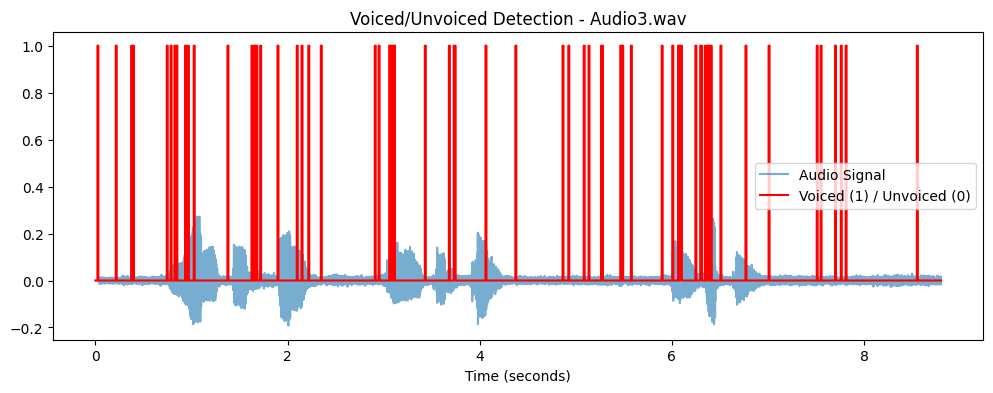

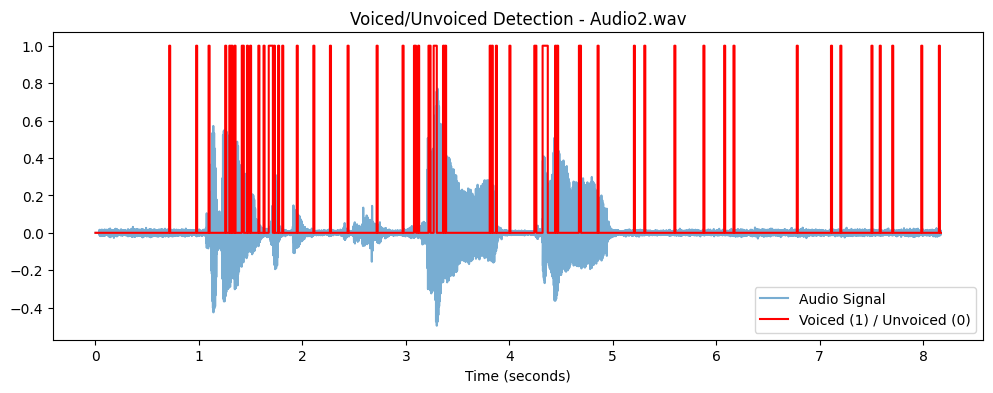

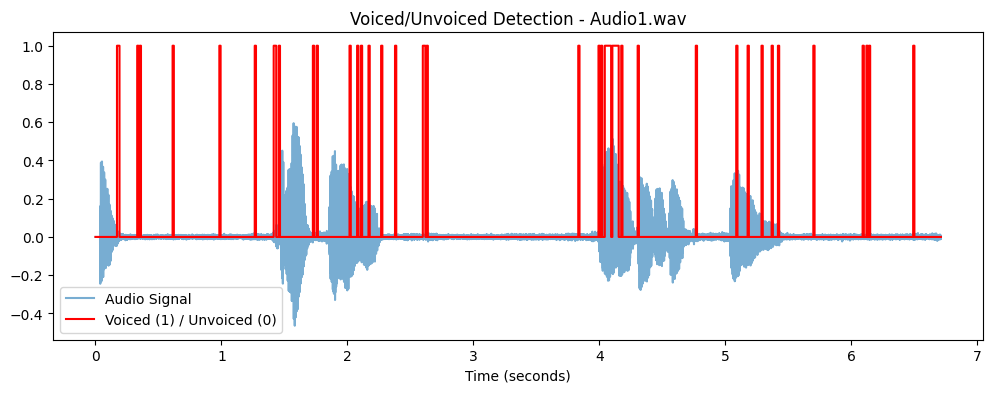

In [ ]:
import matplotlib.pyplot as plt

for file in results:
    signal, sr = librosa.load(os.path.join(folder, file), sr=16000)
    voiced = results[file]["voiced"]

    # Create time axis for signal
    time_signal = np.linspace(0, len(signal)/sr, len(signal))

    # Frame time axis
    frame_time = np.linspace(0, len(signal)/sr, len(voiced))

    plt.figure(figsize=(12,4))

    # Plot waveform
    plt.plot(time_signal, signal, alpha=0.6, label="Audio Signal")

    # Plot voiced/unvoiced
    plt.step(frame_time, voiced, where='post', label="Voiced (1) / Unvoiced (0)", color='red')

    plt.title(f"Voiced/Unvoiced Detection - {file}")
    plt.xlabel("Time (seconds)")
    plt.legend()
    plt.show()